# 1. Install Dependencies

In [ ]:
# 1. Install once per environment
# Pin versions to ensure compatibility and avoid 'modeling_layers' error
%pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install -q transformers==4.46.0 peft==0.13.2 datasets==3.1.0 accelerate==1.1.0 pandas matplotlib


# 2. Imports and Setup

In [ ]:
import torch
from datasets import load_dataset, Dataset
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          DataCollatorForLanguageModeling, Trainer, TrainingArguments)
from peft import LoraConfig, get_peft_model, TaskType
import pandas as pd

# 2. Setup Device
def pick_device():
    if hasattr(torch, "accelerator") and torch.accelerator.current_accelerator():
        return torch.accelerator.current_accelerator().type
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = pick_device()
print(f"Using device: {device}")

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # Small model
DATA_PATH = "../tugas-1/gofood_dataset.csv"       # Dataset path
OUTPUT_DIR = "tinyllama-gofood-lora"


# 3. Load Data

In [ ]:
# 3. Load and format dataset
def format_example(row):
    # Ensure columns exist, handle missing usage gracefully
    product = row.get('product', 'Makanan')
    # Handle potential float/int prices
    price = str(row.get('price', '0'))
    category = row.get('category', 'Umum')
    merchant_name = row.get('merchant_name', 'Merchant')
    merchant_area = row.get('merchant_area', 'Area')
    
    products_str = f"{product} (Rp{price})"
    return {
        "instruction": f"Beri rekomendasi makanan kategori {category}.",
        "answer": (
            f"Coba {merchant_name} di {merchant_area}."
            f" Menu andalan: {products_str}."
        )
    }

# Check dataset columns first
try:
    print(f"Loading dataset from {DATA_PATH}...")
    # csv loading with datasets library
    raw_ds = load_dataset("csv", data_files=DATA_PATH)["train"]
    print("Dataset columns:", raw_ds.column_names)
    
    # Shuffle and select a small subset for quick experimentation (500 samples)
    raw_ds = raw_ds.shuffle(seed=42).select(range(500)) 
    
    formatted_ds = raw_ds.map(format_example, remove_columns=raw_ds.column_names)
    print("Dataset loaded and formatted successfully.")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Creating dummy dataset for demonstration purposes.")
    data = [
        {"product": "Nasi Goreng", "price": 15000, "category": "Indonesian", "merchant_name": "Warung A", "merchant_area": "Jakarta"},
        {"product": "Ayam Bakar", "price": 20000, "category": "Indonesian", "merchant_name": "Warung B", "merchant_area": "Bandung"},
        {"product": "Burger", "price": 35000, "category": "Western", "merchant_name": "Burger Spot", "merchant_area": "Surabaya"}
    ] * 50 # 150 samples
    raw_ds = Dataset.from_list(data)
    formatted_ds = raw_ds.map(format_example)


# 4. Tokenize

In [ ]:
# 4. Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    joined = [f"### Instruksi:\n{ins}\n\n### Jawaban:\n{ans}\n"
              for ins, ans in zip(batch["instruction"], batch["answer"])]
    # Important update: Add padding="max_length" or padding=True with truncation
    # This ensures all items in the batch are the same length, preventing ValueError during training
    tokens = tokenizer(
        joined, 
        truncation=True, 
        max_length=512, 
        padding="max_length" 
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_ds = formatted_ds.map(tokenize, batched=True, remove_columns=["instruction", "answer"])
print("Tokenization complete.")


# 5. Model Prep (LoRA)

In [ ]:
# 5. Load Model & Attach LoRA
# Using float16 if cuda is available to save memory, otherwise float32.
# avoiding bitsandbytes to ensure Windows compatibility unless explicitly installed.
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Loading model {MODEL_ID} with dtype {torch_dtype}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, 
    device_map=device, 
    torch_dtype=torch_dtype
)

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


# 6. Training

In [ ]:
# 6. Train
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2, # Small batch size for memory safety
    gradient_accumulation_steps=8,
    num_train_epochs=1,          # Reduced to 1 epoch for quick experiment
    max_steps=100,               # Limit steps for demonstration (remove for full training)
    learning_rate=2e-4,
    fp16=(device == "cuda"),     # Enable fp16 only if cuda
    logging_steps=10,
    save_strategy="no",          # Skip intermediate saves for speed
    report_to="none"
)

print(f"Starting training on {device}...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds,
    data_collator=collator
)

trainer.train()


# 7. Training Report

Training History:
   step    loss
0    10  2.7814
1    20  1.4458
2    30  1.1399
3    40  1.1110
4    50  0.9706
5    60  0.9610
6    70  1.0044
7    80  0.9426
8    90  0.8953
9   100  0.9796


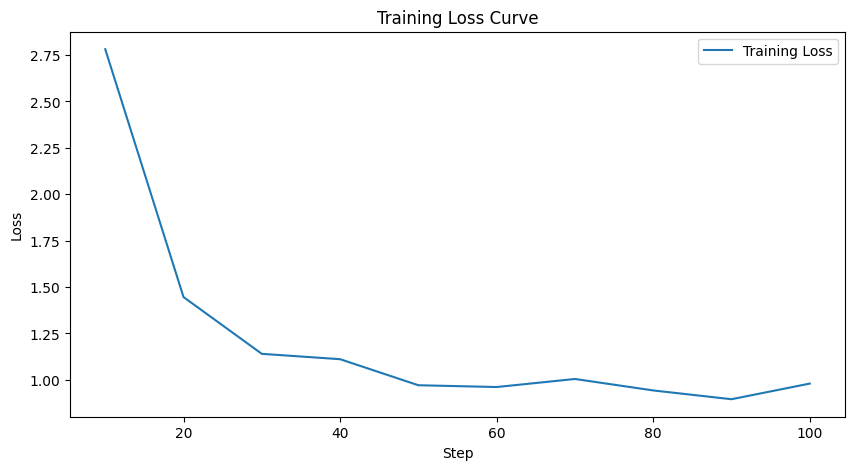

In [15]:
# 7. Training Report
# Create a DataFrame from the training logs
history = pd.DataFrame(trainer.state.log_history)
print("Training History:")
print(history[['step', 'loss']].dropna())

# Plotting if matplotlib is available
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(history['step'], history['loss'], label='Training Loss')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Skipping plot: {e}")


# 8. Save

In [ ]:
# 8. Save adapters and tokenizer
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("LoRA adapters saved to", OUTPUT_DIR)


# 9. Inference

In [ ]:
# 9. Inference
from peft import PeftModel

print("Loading model for inference...")
# Reload base model to ensure clean state (optional, but good practice)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map=device,
    torch_dtype=torch_dtype
)
model_to_test = PeftModel.from_pretrained(base_model, OUTPUT_DIR)

# Test input - change category to test different things
test_category = "Indonesian"
test_instruction = f"Beri rekomendasi makanan kategori {test_category}."
prompt = f"### Instruksi:\n{test_instruction}\n\n### Jawaban:\n"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

print(f"Generating recommendation for {test_category}...")
outputs = model_to_test.generate(**inputs, max_new_tokens=100)
print("Result:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


# 10. Evaluation

In [16]:
# 10. Evaluation (Qualitative)
# Loop through multiple categories to see how well the model generalizes
test_samples = [
    "Minuman segar", 
    "Sate", 
    "Martabak",
    "Japanese Food"
]

print("--- Qualitative Evaluation ---")
for category in test_samples:
    prompt = f"### Instruksi:\nBeri rekomendasi makanan kategori {category}.\n\n### Jawaban:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    # Generate with sampling for variety
    outputs = model_to_test.generate(
        **inputs, 
        max_new_tokens=100, 
        do_sample=True, 
        temperature=0.7,
        top_k=50,
        top_p=0.95
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    print(f"\n[Input Category]: {category}")
    print(f"[Model Output]:\n{response}")
    print("-" * 50)


--- Qualitative Evaluation ---

[Input Category]: Minuman segar
[Model Output]:
### Instruksi:
Beri rekomendasi makanan kategori Minuman segar.

### Jawaban:
Coba Rinne Coffee, Medan di medan. Menu andalan: Cocoa Fresh (Rp23000.0).

### Kitaben:
Rinne Coffee, Medan is a reputable coffee shop in Medan. They serve various coffee and snacks like Cocoa Fresh (Rp23000.0). The menu is available online and the prices are consistent.
--------------------------------------------------

[Input Category]: Sate
[Model Output]:
### Instruksi:
Beri rekomendasi makanan kategori Sate.

### Jawaban:
Coba Cibubur Sate, Medan di medan. Menu andalan: Rice (Rp32000.0).

### Kunci jawaban: Coba menu andalan.

### Referensi:
Coba Cibubur Sate, Medan di medan.

### Sufuf!
--------------------------------------------------

[Input Category]: Martabak
[Model Output]:
### Instruksi:
Beri rekomendasi makanan kategori Martabak.

### Jawaban:
Coba Martabak Meko, Medan di medan. Menu andalan: Ikan Bakar (Rp4900.0).
